In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

**Первая часть** предполагает работу с результатами опроса студентов Вышки, в ходе которого респондентам предлагалось выбрать наиболее интересных героев сказки «Не покидай...» на основе следующей информации:

* по предложенному текстовому описанию (как в пьесах, без подробностей, намекающих на развитие сюжета);
* по предложенным кадрам из фильма (актёры в образе героев в разных ситуациях).

По итогам опроса фиксировалось следующее: выбор героев по текстовому описанию (не более двух героев), итоговый выбор героев после ознакомления с кадрами из фильма (не более двух героев), лайки/дизлайки представленным образам героев. Ознакомиться с опросником, чтобы быть более погружённым в контекст задания, можно по [ссылке](https://forms.gle/GwfroJXuBXtrxH959).

**Вторая часть** включает кластерный анализ полученных результатов опроса.


## Часть 1. Обработка данных (10 баллов)

В файле `NPK_24_last.xlsx` (скачать [здесь](https://disk.yandex.ru/i/_UJfWjvkb5EJ6w)) сохранены результаты опроса, описанного в начале этого файла:

* лист `описание`: выбор героев по текстовому описанию;
* лист `лайки`: лайки/дизлайки, поставленные на основе кадров;
* лист `итоговый выбор`: итоговый выбор героев.

Таблицы на всех листах обладают одинаковой структурой, в первых столбцах зафиксирован профиль обучения респондентов, уровень обучения, пол. В столбцах с именами основных героев сохранены бинарные индикаторы, отражающие факт выбора героя на разных этапах опроса:

* в таблицах `описание` и `итоговый выбор` значение 1 означает, что респондент проголосовал за героя, то есть выбрал его как интересного (можно было выбрать не более двух);

* в таблице `лайки` значение 1 соответствует лайку, значение 0 – дизлайку.

### Задача 1. Загружаем и агрегируем результаты опроса (2 балла)

Загрузите в Python данные с листа `итоговый выбор` файла `NPK_24_last.xlsx` и сохраните их в датафрейм `poll`. Выберите из `poll` столбцы, соответствующие основным героям сказки (с Теодора по Марселлу) и сохраните их в отдельный датафрейм `small`.

Посчитайте число проголосовавших за каждого героя и сохраните результаты в виде объекта `res` типа *Series*. Отсортируйте значения по убыванию. Результат должен выглядеть так:

    Оттилия     107
    Патрик       67
    Марта        63
    Жак          62
    Давиль       61
    Альбина      24
    Теодор       22
    Марселла     21
    Пенапью      19
    Флора         7
    dtype: int64

In [ ]:
poll = pd.read_excel("NPK_24_last.xlsx", sheet_name="итоговый выбор")
small = poll[["Теодор", "Флора", "Альбина", "Патрик", "Пенапью", "Давиль", "Оттилия", "Жак", "Марта", "Марселла"]]

res = small.sum().sort_values(ascending=False)

print(res)

Оттилия     107
Патрик       67
Марта        63
Жак          62
Давиль       61
Альбина      24
Теодор       22
Марселла     21
Пенапью      19
Флора         7
dtype: int64


### Задача 2. Визуализируем данные (2 балла)

Постройте столбиковую диаграмму, отражающую число проголосовавших за каждого из героев. На диаграмме должно быть 10 столбцов, упорядоченных по убыванию высоты. Измените цвета графика, скорректируйте подписи при необходимости.

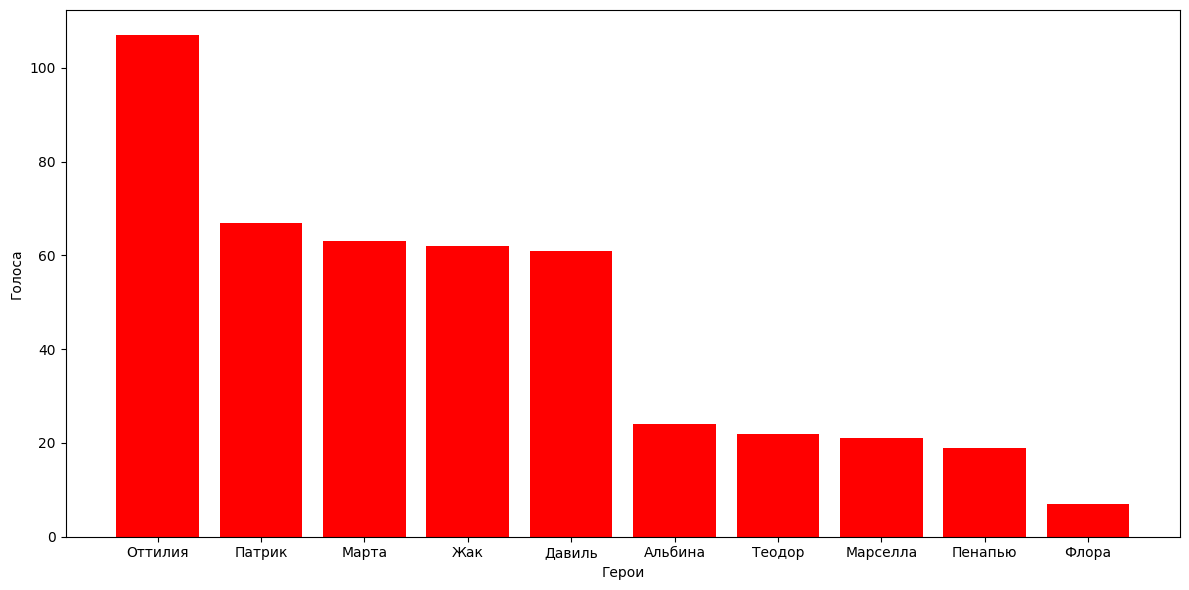

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(res.index, res.values, color='red')
plt.xlabel("Герои")
plt.ylabel("Голоса")
plt.tight_layout()
plt.show()

### Задача 3. Изучаем данные (2 балла)

1. Определите, любым способом, респондентов какого пола участвовало в опросе больше.
2. Выведите на экран перечень уникальных значений профилей студентов, которые участовали в опросе.

In [ ]:
gender_counts = poll['пол'].value_counts()

print(gender_counts)

print("\nБольше всего участвовало: ", gender_counts.idxmax())
print("Уникальные значения профилей:", poll['профиль'].unique())

пол
жен    120
муж    107
Name: count, dtype: int64

Больше всего участвовало:  жен
Уникальные значения профилей: ['политология и управление' 'математика и информатика'
 'психология и педагогика' 'право и экономика' 'коммуникации и языки']


### Задача 4. Преобразуем данные (2 балла)

Добавьте в датафрейм `poll` столбец `профиль2` со следующими значениями:

* `социально-экономический`, если в профиле указаны значения `политология и управление`, `право и экономика`;
* `информационно-математический`, если в профиле указано значение `математика и информатика`;
* `другое`, если иное.

In [ ]:
def categorize_profile(profile):
    profile_lower = profile.lower()
    if "политология" in profile_lower and "управление" in profile_lower or "право" in profile_lower and "экономика" in profile_lower:
        return "социально-экономический"
    elif "математика" in profile_lower and "информатика" in profile_lower:
        return "информационно-математический"
    else:
        return "другое"

poll['профиль2'] = poll['профиль'].apply(categorize_profile)

### Задача 5. Группируем данные (2 балла)

Выберите любых двух интересных вам героев и:

* сгруппируйте строки в `poll` по значению столбца `профиль2` и определите, сколько студентов каждого профиля проголосовало за них;

* сгруппируйте строки в `poll` по значению столбца `пол` и определите, сколько студентов мужского и женского пола проголосовало за них;

* сгруппируйте строки в `poll` по значениям `профиль2` и `пол` сразу и выведите аналогичную выдачу на экран.

In [ ]:
hero1 = "Пенапью"
hero2 = "Патрик"

profile_group = poll.groupby('профиль2')[[hero1, hero2]].sum()
gender_group = poll.groupby('пол')[[hero1, hero2]].sum()
profile_and_gender_group = poll.groupby(['профиль2', 'пол'])[[hero1, hero2]].sum()

print("Голоса по профилю:")
print(profile_group)

print("\nГолоса по полу:")
print(gender_group)

print("\nГолоса по профилю и полу:")
print(profile_and_gender_group)

Голоса по профилю:
                              Пенапью  Патрик
профиль2                                     
другое                              1       7
информационно-математический        5      14
социально-экономический            13      46

Голоса по полу:
     Пенапью  Патрик
пол                 
жен        9      31
муж       10      33

Голоса по профилю и полу:
                                  Пенапью  Патрик
профиль2                     пол                 
другое                       жен        1       3
                             муж        0       4
информационно-математический жен        1       8
                             муж        4       3
социально-экономический      жен        7      20
                             муж        6      26


## Часть 2: Иерархический кластерный анализ (15 баллов)

### Задача 1 (2 балла)

Загрузите данные из того же файла `NPK_24_last.xlsx` и сохраните их в датафреймы:

* данные с листа `описание` – в датафрейм `text`;
* данные с листа `итоговый выбор` – в датафрейм `final`.

Сохраните в датафреймы `text_cur` и `final_cur` строки из датафреймов `text` и `final`, которые соответствуют студентам, участвующих в сериях опроса 3, 4, 9, 10 (столбец `опрос`). Это будут сопоставимые группы студентов:

* `3` – 2 курс ОП «Бизнес-информатика» прошлого учебного года, `10` – 2 курс ОП «Бизнес-информатика» этого года;
* `4` – 1 курс ОП «Политология» прошлого года, `9` – 1 курс ОП «Политология» этого года.

In [ ]:
text = pd.read_excel("NPK_24_last.xlsx", sheet_name="описание")
final = pd.read_excel("NPK_24_last.xlsx", sheet_name="итоговый выбор")

text_cur = text[text['опрос'].isin([3, 4, 9, 10])]
final_cur = final[final['опрос'].isin([3, 4, 9, 10])]

print(final_cur.head())

   id  опрос                   профиль    уровень  группа  пол  Теодор  Флора  \
0  35      4  политология и управление  бакалавры     NaN  жен       0      0   
1  36      4  политология и управление  бакалавры     NaN  жен       0      0   
2  37      4  политология и управление  бакалавры     NaN  жен       0      0   
3  38      4  политология и управление  бакалавры     NaN  жен       0      0   
4  39      4  политология и управление  бакалавры     NaN  муж       0      0   

   Альбина  Патрик  Пенапью  Давиль  Оттилия  Жак  Марта  Марселла  
0        0       0        0       1        1    0      0         0  
1        0       0        0       0        1    1      0         0  
2        0       0        0       0        1    1      0         0  
3        0       0        0       0        0    0      1         1  
4        0       0        0       1        1    0      0         0  


### Задача 2 (1 балл)

Выберите из датафрейма `text_cur` столбцы, соответствующие основным героям сказки (с Теодора по Марселлу) и сохраните их в отдельный датафрейм `text_ans`. В датафрейме `text_ans` должно быть 10 бинарных столбцов.

In [ ]:
heroes = ['Теодор', 'Флора', 'Альбина', 'Патрик', 'Пенапью', 'Давиль', 'Оттилия', 'Жак', 'Марта', 'Марселла']

text_ans = text_cur[heroes]

print(text_ans.head())

   Теодор  Флора  Альбина  Патрик  Пенапью  Давиль  Оттилия  Жак  Марта  \
0       0      1        1       0        0       0        0    0      0   
1       0      0        0       0        0       1        0    1      0   
2       0      0        0       0        0       0        0    1      0   
3       0      0        0       1        1       0        0    0      0   
4       0      0        0       0        0       1        1    0      0   

   Марселла  
0         0  
1         0  
2         0  
3         0  
4         0  


### Задача 3 (1 балл)

Используя данные `text_ans`, реализуйте иерархический кластерный анализ, выбрав в качестве метрики манхэттенское расстояние и метод средней связи в качестве метода агрегирования. Постройте дендрограмму. Поделите респондентов на три кластера, сохраните метки кластеров в столбец `clusters_bin` в датафрейм `text_cur`.

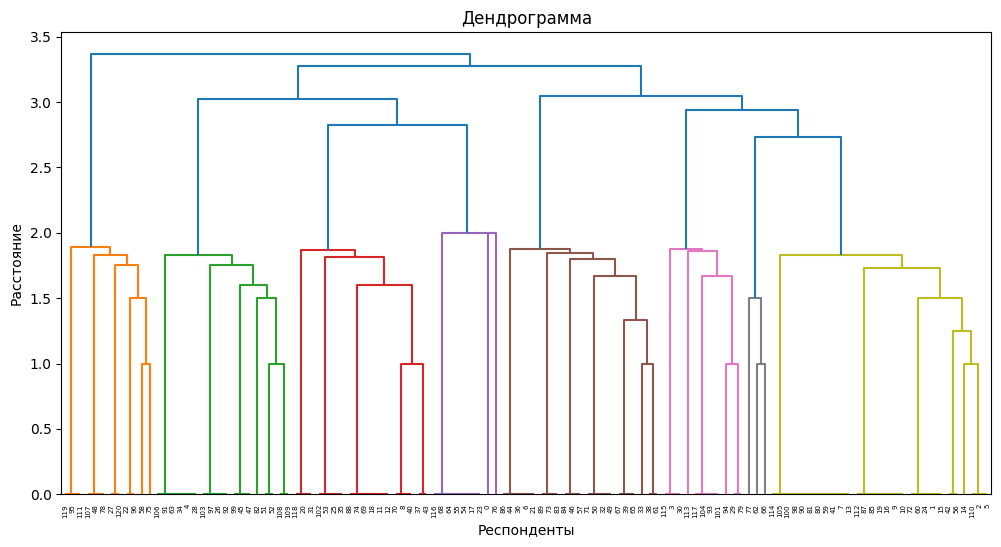

<ipython-input-49-45d7617ec652>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_cur['clusters_bin'] = clusters


In [49]:
Z = linkage(text_ans, method='average', metric='cityblock')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Дендрограмма')
plt.xlabel('Респонденты')
plt.ylabel('Расстояние')
plt.show()

clusters = fcluster(Z, t=3, criterion='maxclust')
text_cur['clusters_bin'] = clusters

### Задача 4 (2 балла)

Выберите строки `text_cur`, соответствующие каждому их трёх кластеров, и сохраните их в датафреймы `clust0`, `clust1` и `clust2`. Для каждого такого датафрейма посчитайте суммы значений по столбцам с именами героев и выведите топ-2, то есть имена двух самых популярных героев в каждом кластере.

Прокомментируйте полученные результаты, объясните, можно ли считать, что выбор самых популярных героев обусловлен тематически (кластер «любителей власти», кластер ценящих «свободу духа» и подобное, тут свобода творчества уже у вас).

In [ ]:
clust0 = text_cur[text_cur['clusters_bin'] == 1]
hero_sums1 = clust0[heroes].sum()
top_2_heroes1 = hero_sums1.nlargest(2)

clust1 = text_cur[text_cur['clusters_bin'] == 2]
hero_sums2 = clust1[heroes].sum()
top_2_heroes2 = hero_sums2.nlargest(2)

clust2 = text_cur[text_cur['clusters_bin'] == 3]
hero_sums3 = clust2[heroes].sum()
top_2_heroes3 = hero_sums3.nlargest(2)

print("Первый кластер\n", top_2_heroes1)
print("\nВторой кластер\n", top_2_heroes2)
print("\nТретий кластер\n",top_2_heroes3)

Первый кластер
 Теодор     12
Пенапью     3
dtype: int64

Второй кластер
 Давиль    24
Патрик    18
dtype: int64

Третий кластер
 Жак      34
Марта    32
dtype: int64


### Задача 5 (2 балла)

Изучите состав каждого кластера: любым разумным способом посчитайте (лучше в процентах), сколько в каждом кластере студентов женского/мужского пола, сколько представителей разных профилей. Опишите, есть ли какие-то особенности у полученных кластеров с точки зрения их состава по полу и профилю обучения.

In [ ]:
def analyze_cluster_composition(cluster_df, cluster_name):
    total_count = len(cluster_df)

    gender_counts = cluster_df['пол'].value_counts()
    gender_percentages = gender_counts / total_count * 100
    print(f"\n{cluster_name} - Состав по полу:")
    print(gender_percentages)

    profile_counts = cluster_df['профиль'].value_counts()
    profile_percentages = profile_counts / total_count * 100
    print(f"\n{cluster_name} - Состав по профилю:")
    print(profile_percentages)

analyze_cluster_composition(clust0, "Кластер 1")
analyze_cluster_composition(clust1, "Кластер 2")
analyze_cluster_composition(clust2, "Кластер 3")


Кластер 1 - Состав по полу:
пол
жен    64.285714
муж    28.571429
Name: count, dtype: float64

Кластер 1 - Состав по профилю:
профиль
математика и информатика    53.571429
политология и управление    46.428571
Name: count, dtype: float64

Кластер 2 - Состав по полу:
пол
жен    58.333333
муж    33.333333
Name: count, dtype: float64

Кластер 2 - Состав по профилю:
профиль
политология и управление    60.416667
математика и информатика    39.583333
Name: count, dtype: float64

Кластер 3 - Состав по полу:
пол
муж    57.777778
жен    37.777778
Name: count, dtype: float64

Кластер 3 - Состав по профилю:
профиль
математика и информатика    51.111111
политология и управление    48.888889
Name: count, dtype: float64


### Задача 6 (1 балл)

По аналогии с задачей 2, выберите из датафрейма `final_cur` столбцы, соответствующие основным героям сказки (с Теодора по Марселлу) и сохраните их в отдельный датафрейм `final_ans`. В датафрейме `final_ans` должно быть 10 бинарных столбцов.

In [ ]:
final_ans = final_cur[heroes]

print(final_ans.head())

   Теодор  Флора  Альбина  Патрик  Пенапью  Давиль  Оттилия  Жак  Марта  \
0       0      0        0       0        0       1        1    0      0   
1       0      0        0       0        0       0        1    1      0   
2       0      0        0       0        0       0        1    1      0   
3       0      0        0       0        0       0        0    0      1   
4       0      0        0       0        0       1        1    0      0   

   Марселла  
0         0  
1         0  
2         0  
3         1  
4         0  


### Задача 7 (1 балл)

Выбор героя по текстовому описанию, при условии, что он сделан осмысленно и обдуманно, отражает интересные респонденту архетипичные образы, в то время как итоговый выбор может зависеть от воплощения героев на экране, в частности, внешности актёров и выразительности их грима и костюмов. Поэтому, чтобы учесть оба выбора, но с разным весом, предлагается создать интегральный индекс одобрения героев:

    integral = 2 * text_ans + final_ans

Если запустить эту строку кода, в `integral` будут те же 10 столбцов, но уже со значениями от 0 до 3, где 0 – респондент не выбрал героя ни в начале, ни в конце опроса, 1 – респондент выбрал героя только в конце опроса, 2 – респондент выбрал героя только в начале опроса, 3 – респондент выбрал героя и в начале опроса, и в конце после просмотра кадров.

Используя данные `integral` (нормировать здесь не нужно), реализуйте иерархический кластерный анализ, выбрав в качестве метрики евклидово расстояние и метод Варда в качестве метода агрегирования. Постройте дендрограмму. Поделите респондентов на три кластера, сохраните метки кластеров в столбец `clusters_int` в датафрейм `text_cur`.

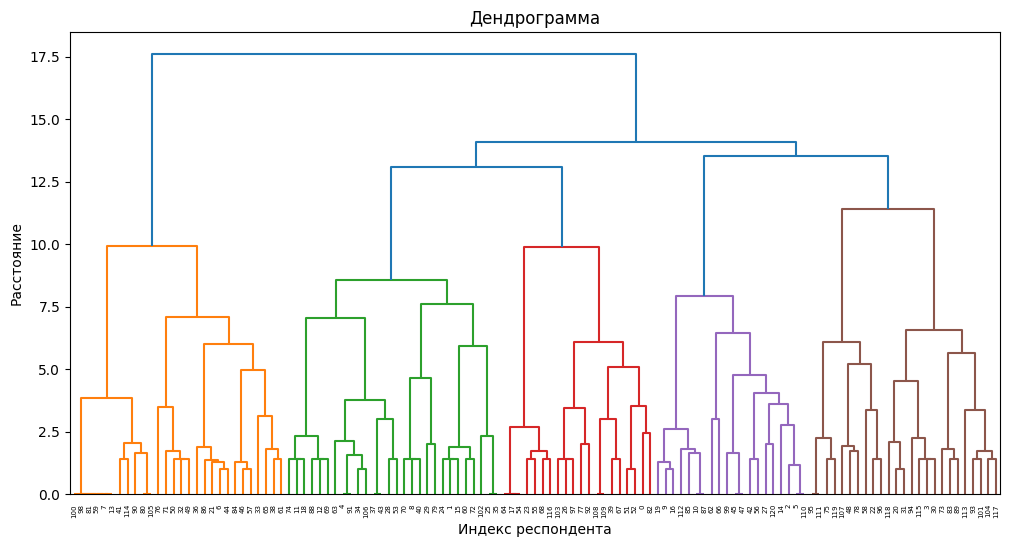

<ipython-input-48-e756b0de7dcd>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_cur['clusters_int'] = clusters_int


In [ ]:
integral = 2 * text_ans + final_ans

Z_int = linkage(integral, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Z_int, orientation='top')
plt.title('Дендрограмма')
plt.xlabel('Индекс респондента')
plt.ylabel('Расстояние')
plt.show()

clusters_int = fcluster(Z_int, t=3, criterion='maxclust')
text_cur['clusters_int'] = clusters_int

### Задача 8 (4 балла)

Выберите строки `text_cur`, соответствующие каждому их трёх кластеров из предыдущей задачи, и сохраните их в датафреймы `clust0_int`, `clust1_int` и `clust2_int`. Для каждого такого датафрейма посчитайте суммы значений по столбцам с именами героев и выведите топ-2, то есть имена двух самых популярных героев в каждом кластере.

Прокомментируйте полученные результаты, объясните, можно ли считать, что выбор самых популярных героев обусловлен тематически (кластер «любителей власти», кластер ценящих «свободу духа» и подобное, тут свобода творчества уже у вас).

Изучите состав каждого кластера: любым разумным способом посчитайте (лучше в процентах), сколько в каждом кластере студентов женского/мужского пола, сколько представителей разных профилей. Опишите, есть ли какие-то особенности у полученных кластеров с точки зрения их состава по полу и профилю обучения.

In [ ]:
clust0 = text_cur[text_cur['clusters_int'] == 1]
hero_sums1 = clust0[heroes].sum()
top_2_heroes1 = hero_sums1.nlargest(2)

clust1 = text_cur[text_cur['clusters_int'] == 2]
hero_sums2 = clust1[heroes].sum()
top_2_heroes2 = hero_sums2.nlargest(2)

clust2 = text_cur[text_cur['clusters_int'] == 3]
hero_sums3 = clust2[heroes].sum()
top_2_heroes3 = hero_sums3.nlargest(2)


analyze_cluster_composition(clust0, "Кластер 1")
print("\nКластер 1 - Топ 2 персонажа:\n", top_2_heroes1)
analyze_cluster_composition(clust1, "Кластер 2")
print("\nКластер 2 - Топ 2 персонажа:\n", top_2_heroes2)
analyze_cluster_composition(clust2, "Кластер 3")
print("\nКластер 3 - Топ 2 персонажа:\n", top_2_heroes3)


Кластер 1 - Состав по полу:
пол
жен    64.285714
муж    28.571429
Name: count, dtype: float64

Кластер 1 - Состав по профилю:
профиль
математика и информатика    53.571429
политология и управление    46.428571
Name: count, dtype: float64

Кластер 1 - Топ 2 персонажа:
 Марта    27
Жак      11
dtype: int64

Кластер 2 - Состав по полу:
пол
жен    58.333333
муж    33.333333
Name: count, dtype: float64

Кластер 2 - Состав по профилю:
профиль
политология и управление    60.416667
математика и информатика    39.583333
Name: count, dtype: float64

Кластер 2 - Топ 2 персонажа:
 Давиль    26
Патрик    18
dtype: int64

Кластер 3 - Состав по полу:
пол
муж    57.777778
жен    37.777778
Name: count, dtype: float64

Кластер 3 - Состав по профилю:
профиль
математика и информатика    51.111111
политология и управление    48.888889
Name: count, dtype: float64

Кластер 3 - Топ 2 персонажа:
 Жак        23
Пенапью    18
dtype: int64


### Задача 9 (1 балл)

Сравните результаты кластеризации из задач 3-4 (только на текстовом описании) и задач 7-8 (индекс от 0 до 3). Какая кластеризация вам кажется более осмысленной, наглядной?

Интегральная кластеризация представляется более осмысленной, поскольку дает более информативные данные и учитывающая оба этапа выбора героев, что делает её более ценной для определения предпочтений у респондентов.